In [1]:
"""
Temperature Forecast Data Preparation
--------------------------------------

Target:
    y = T_anom(t + lead)

Dynamic predictors (lagged):
    T_anom
    ea
    pna
    nino34
    nino12
    aao
    heatcentra

Static predictors:
    lat, lon, elevation

Seasonal predictors:
    sin_month, cos_month

No modeling performed.
"""

import sqlite3
import pandas as pd
import numpy as np
import duckdb

# ============================================================
# CONFIGURATION
# ============================================================
path="/home/joe/work/Fire/ML/Data"
path_clim="/home/joe/work/Fire/ML/Data/Climate-Indices/New"

#ERA_DB = f"{path}era5DataMeans.db"
ERA_DB = f"{path}/DB/era5MonthlyMeansFinal.sqlite"
#ERA_TABLE = "MEANS_TTdRHVPD"
ERA_TABLE = "monthly_means"
CLIMATE_DB = f"{path_clim}/climate_indices.db"
CLIMATE_TABLE = "indices"

POINT_META_CSV = f"{path}/latlon_elevation.csv"

#T_VAR = "T"
T_VAR = "Td"
# T_VAR = "RH"
# T_VAR = "VPD"

# TARGET_VAR = "u"

# 'point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
#        'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
#        'days_with_vpd_gt_3'

columns = {"T":"t_mean", "Td":"td_mean", "RH":"rh_mean", "VPD":"vpd_mean"}

TARGET_VAR = columns[T_VAR]


# Train climatology window
TRAIN_CLIMO_START_YM = 1990 * 12 + 1
TRAIN_CLIMO_END_YM   = 2015 * 12 + 12

# Leads
LEADS = list(range(1, 13))

# Lags applied to ALL dynamic predictors
LAG_MONTHS = [0,1,2,3,6,24]
# LAG_MONTHS = list(range(0, 7))

# Train / test split
TEST_START_YM = 2016 * 12 + 1

columns = {"T":"t_mean", "Td":"td_mean", "RH":"rh_mean", "VPD":"vpd_mean"}

TARGET_VAR = columns[T_VAR]


## Define Grid
GRID_RADIUS_DEG = 0.21
LATT = 41.0
LATB = 37.0
LONL = -109.0
LONR = -102.0
R = .1
STEP = 5


## Get Data

In [ ]:


# ============================================================
# LOAD ERA DATA
# ============================================================

def load_era():
    # conn = sqlite3.connect(ERA_DB)
    # df = pd.read_sql(f"SELECT * FROM {ERA_TABLE}", conn)
    # conn.close()
    con = duckdb.connect("/home/joe/work/Fire/ML/Data/DB/era5MonthlyMeansFinal.sqlite")

    df = con.execute(f"""
    SELECT * FROM {ERA_TABLE}
    """).df()

    con.close()
# 'point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
#        'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
#        'days_with_vpd_gt_3'


 #   df = df.rename(columns={"Point": "point_id"})
    df["year_month"] = df["year_month"].astype(int)
    df["year"] = df["year_month"] // 100
    df["month"] = df["year_month"] % 100
    df["ym_index"] = df["year"] * 12 + df["month"]

    print(f"ERA  ", df.columns)

    return df


# ============================================================
# LOAD CLIMATE INDICES
# ============================================================

def load_indices():
    conn = sqlite3.connect(CLIMATE_DB)
    idx = pd.read_sql(f"SELECT * FROM {CLIMATE_TABLE}", conn)
    conn.close()

    # idx = idx.rename(columns={
    #     "ea.data": "ea",
    #     "pna.data": "pna",
    #     "nino34.long.anom.data": "nino34",
    #     "nino12.long.anom.data": "nino12",
    #     "aao.data": "aao",
    #     "heatcentra.data": "heatcentra"
    # })

    return idx


# ============================================================
# LOAD METADATA
# ============================================================

def load_metadata():
    meta = pd.read_csv(POINT_META_CSV)
    meta = meta.rename(columns={
        "point": "point_id",
        "latitude": "lat",
        "longitude": "lon",
        "elevation_m": "elevation"
    })
    return meta


# ============================================================
# MERGE DATA
# ============================================================

def merge_all():
    df = load_era()
    print("df cols:", df.columns)
    idx = load_indices()
    indicesCols = idx.drop(columns=["yrmo"]).columns

    meta = load_metadata()

    df = df.merge(idx, left_on="year_month", right_on="yrmo", how="left")
    df = df.drop(columns=["yrmo"])

    df = df.merge(meta, on="point_id", how="left")
    print("data",df.tail())
    return df,indicesCols


# ============================================================
# SPATIAL SUBSET (25 POINT MESH)
# ============================================================

def apply_mesh(df, center_point):
    center = df.loc[df.point_id == center_point].iloc[0]
    print(f"Center point: ID {center['point_id']}, lat {center['lat']:.3f}, lon {center['lon']:.3f}" )
    df = df[
        (np.abs(df.lat - center['lat']) <= GRID_RADIUS_DEG) &
        (np.abs(df.lon - center['lon']) <= GRID_RADIUS_DEG)
    ].copy()
    print("POINTS ", df['point_id'].unique())
    return df


# ============================================================
# CLIMATOLOGY + ANOMALY
# ============================================================

def compute_climatology(df):
    mask = (
        (df.ym_index >= TRAIN_CLIMO_START_YM) &
        (df.ym_index <= TRAIN_CLIMO_END_YM)
    )

    climo = (
        df.loc[mask]
          .groupby(["point_id", "month"], as_index=False)[TARGET_VAR]
          .mean()
          .rename(columns={TARGET_VAR: "T_climo"})
    )

    return climo


def apply_anomaly(df, climo):
    df = df.merge(climo, on=["point_id", "month"], how="left")
    df["T_anom"] = df[TARGET_VAR] - df["T_climo"]
    return df


# ============================================================
# SEASONAL FEATURES
# ============================================================

def add_seasonality(df):
    df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)
    return df




def add_lags(df,DYNAMIC_FEATURES):
    df = df.sort_values(["point_id", "ym_index"])

    for feature in DYNAMIC_FEATURES:
        for lag in LAG_MONTHS:
            df[f"{feature}_lag{lag}"] = (
                df.groupby("point_id")[feature].shift(lag)
            )

    return df


# ============================================================
# BUILD FORECAST TABLE
# ============================================================

def build_forecast(df,DYNAMIC_FEATURES):

    lagged_cols = [
        f"{feat}_lag{lag}"
        for feat in DYNAMIC_FEATURES
        for lag in LAG_MONTHS
    ]

    rows = []

    for pid, df_p in df.groupby("point_id"):
        df_p = df_p.reset_index(drop=True)

        for i, issue in df_p.iterrows():

            for lead in LEADS:

                j = i + lead
                if j >= len(df_p):
                    continue

                target = df_p.loc[j]

                row = {
                    "point_id": pid,
                    "issue_ym": issue.ym_index,
                    "lead": lead,
                    "target_ym": target.ym_index,
                    "y": target["T_anom"],
                    "lat": issue.lat,
                    "lon": issue.lon,
                    "elevation": issue.elevation,
                    "sin_month": issue.sin_month,
                    "cos_month": issue.cos_month
                }
                row["issue_year"] = int(issue.year)
                row["issue_month"] = int(issue.month)

                row["target_year"] = int(target.year)
                row["target_month"] = int(target.month)




                for col in lagged_cols:
                    row[col] = issue[col]

                rows.append(row)

    forecast_df = pd.DataFrame(rows)

    forecast_df = forecast_df.dropna(subset=lagged_cols).reset_index(drop=True)

    return forecast_df, lagged_cols


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

def train_test_split(forecast_df, lagged_cols):

    feature_cols = (
        lagged_cols +
        ["lead", "lat", "lon", "elevation", "sin_month", "cos_month"]
    )

    train_df = forecast_df[forecast_df.issue_ym < TEST_START_YM].copy()
    test_df  = forecast_df[forecast_df.issue_ym >= TEST_START_YM].copy()

    X_train = train_df[feature_cols].copy()
    y_train = train_df["y"].copy()

    X_test  = test_df[feature_cols].copy()
    y_test  = test_df["y"].copy()

    return X_train, X_test, y_train, y_test, train_df, test_df


# ============================================================
# MASTER PIPELINE
# ============================================================

def prepare_dataset(center_point):

    df,indCols = merge_all()
    DYNAMIC_FEATURES = [
        "T_anom"
    ] + list(indCols)

    print("DYNAMIC_FEATURES:", DYNAMIC_FEATURES)

    dfOrg = df.copy()
    df = apply_mesh(df, center_point)
    por_stats=df.groupby([ "month"])[TARGET_VAR].agg(['mean', 'std']).reset_index()

    climo = compute_climatology(df)
    df = apply_anomaly(df, climo)

    df = add_seasonality(df)
    df = add_lags(df,DYNAMIC_FEATURES)

    forecast_df, lagged_cols = build_forecast(df,DYNAMIC_FEATURES)

    return train_test_split(forecast_df, lagged_cols),por_stats,dfOrg,df,forecast_df,DYNAMIC_FEATURES




def getMeshPoints(R, latT,latB,lonL,lonR,STEP=5):
    # Grid definition
    lat_vals = np.round(np.arange(latT, latB -R, -R), 1)
    lon_vals = np.round(np.arange(lonL, lonR + R, R), 1)

    lat_core = lat_vals[2:-2]   # drop top 2 + bottom 2
    lon_core = lon_vals[2:-2]   # drop left 2 + right 2

    lat_centers = lat_core[::STEP]
    lon_centers = lon_core[::STEP]

    mesh_centers = []

    for lat in lat_centers:
        for lon in lon_centers:
            mesh_centers.append((lat, lon))

    return mesh_centers



# ============================================================
# EXECUTE
# ============================================================

if __name__ == "__main__":
    mc = getMeshPoints(R,LATT,LATB,LONA,LONB,STEP)
    center_point = 1116

    (X_train, X_test, y_train, y_test, train_df, test_df), por_stats, dfOrg, df,fdf,DYNAMIC_FEATURES = prepare_dataset(center_point)

    print("X_train shape:", X_train.shape)
    print("X_test shape :", X_test.shape)
    print("Number of features:", X_train.shape[1])


NameError: name 'mc' is not defined

## New Extract

In [1]:
import sqlite3
import pandas as pd
import duckdb
import numpy as np

import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import pickle
# ============================================================
# CONFIG
# ============================================================
path = "/home/joe/work/Fire/ML/Data"
path_clim = "/home/joe/work/Fire/ML/Data/Climate-Indices/New"

ERA_DB = f"{path}/DB/era5MonthlyMeansFinal.sqlite"
ERA_TABLE = "monthly_means"

CLIMATE_DB = f"{path_clim}/climate_indices.db"
CLIMATE_TABLE = "indices"

POINT_META_CSV = f"{path}/latlon_elevation.csv"
#T_VAR = "T"
T_VAR = "Td"

columns = {"T":"t_mean", "Td":"td_mean", "RH":"rh_mean", "VPD":"vpd_mean"}

TARGET_VAR = columns[T_VAR]
TRAIN_CLIMO_START_YM = 1990 * 12 + 1
TRAIN_CLIMO_END_YM   = 2015 * 12 + 12

# Leads
LEADS = list(range(1, 13))

# Lags applied to ALL dynamic predictors
LAG_MONTHS = [0,1,2,3,6,24]
# LAG_MONTHS = list(range(0, 7))

# Train / test split
TEST_START_YM = 2016 * 12 + 1


## Define Grid
GRID_RADIUS_DEG = 0.21
LATT = 41.0
LATB = 37.0
LONL = -109.0+360
LONR = -102.0+360
R = .1
STEP = 5

# ============================================================
# GLOBAL LOADERS
# ============================================================
def load_era_global():
    con = duckdb.connect(ERA_DB)
    df = con.execute(f"SELECT * FROM {ERA_TABLE}").df()
    con.close()

    df["year_month"] = df["year_month"].astype(int)
    df["year"] = df["year_month"] // 100
    df["month"] = df["year_month"] % 100
    df["ym_index"] = df["year"] * 12 + df["month"]

    return df


def load_indices_global():
    conn = sqlite3.connect(CLIMATE_DB)
    idx = pd.read_sql(f"SELECT * FROM {CLIMATE_TABLE}", conn)
    conn.close()
    return idx


def load_metadata_global():
    meta = pd.read_csv(POINT_META_CSV)
    meta = meta.rename(columns={
        "point": "point_id",
        "latitude": "lat",
        "longitude": "lon",
        "elevation_m": "elevation"
    })
    return meta


def extract_mesh(df_full, center_lat, center_lon, spacing=0.1, radius=2):

    delta = spacing * radius + .01

    df_mesh = df_full[
        (df_full["lat"] >= center_lat - delta) &
        (df_full["lat"] <= center_lat + delta) &
        (df_full["lon"] >= center_lon - delta) &
        (df_full["lon"] <= center_lon + delta)
    ].copy()
    print(f"Extracted mesh around ({center_lat}, {center_lon}) with {len(df_mesh['point_id'].unique())} unique points." )
    return df_mesh


def getCenterPoints(R, latT,latB,lonL,lonR,STEP=5):
    # Grid definition
    lat_vals = np.round(np.arange(latT, latB -R, -R), 1)
    lon_vals = np.round(np.arange(lonL, lonR + R, R), 1)

    lat_core = lat_vals[2:-2]   # drop top 2 + bottom 2
    lon_core = lon_vals[2:-2]   # drop left 2 + right 2

    lat_centers = lat_core[::STEP]
    lon_centers = lon_core[::STEP]

    mesh_centers = []

    for lat in lat_centers:
        for lon in lon_centers:
            mesh_centers.append((lat, lon))

    return mesh_centers

def add_seasonality(df):
    df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)
    return df


def add_lags(df,DYNAMIC_FEATURES):
    print("Adding lags for features:", DYNAMIC_FEATURES)
    print(df.head())
    df.rename(columns={"point_id_x": "point_id"}, inplace=True)
    df = df.sort_values(["point_id", "ym_index"])

    for feature in DYNAMIC_FEATURES:
        for lag in LAG_MONTHS:
            df[f"{feature}_lag{lag}"] = (
                df.groupby("point_id")[feature].shift(lag)
            )

    print("Laggs Finished")
    return df


def build_forecast(df, DYNAMIC_FEATURES):

    print("Building forecast table (vectorized)...")
    print("SHAPE ", df.shape)

    # Lagged columns (same as before)
    lagged_cols = [
        f"{feat}_lag{lag}"
        for feat in DYNAMIC_FEATURES
        for lag in LAG_MONTHS
    ]

    # Sort once
    df = df.sort_values(["point_id", "ym_index"]).copy()

    all_leads = []

    for lead in LEADS:

        df_shift = df.copy()

        # 🔥 FIX: groupby on df_shift, NOT df
        g = df_shift.groupby("point_id")

        df_shift["target_ym"] = g["ym_index"].shift(-lead)
        df_shift["y"] = g["T_anom"].shift(-lead)
        df_shift["target_year"] = g["year"].shift(-lead)
        df_shift["target_month"] = g["month"].shift(-lead)

        df_shift["lead"] = lead

        all_leads.append(df_shift)

    # Stack all leads
    forecast_df = pd.concat(all_leads, ignore_index=True)

    # Issue fields
    forecast_df["issue_ym"] = forecast_df["ym_index"]
    forecast_df["issue_year"] = forecast_df["year"]
    forecast_df["issue_month"] = forecast_df["month"]

    # Final column structure (unchanged)
    base_cols = [
        "point_id",
        "issue_ym",
        "lead",
        "target_ym",
        "y",
        "lat",
        "lon",
        "elevation",
        "sin_month",
        "cos_month",
        "issue_year",
        "issue_month",
        "target_year",
        "target_month",
    ]

    forecast_df = forecast_df[base_cols + lagged_cols]

    # Drop rows with missing targets or lag features
    forecast_df = forecast_df.dropna(subset=["y"] + lagged_cols).reset_index(drop=True)

    print("Forecast table built with shape:", forecast_df.shape)

    return forecast_df, lagged_cols


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

def train_test_split(forecast_df, lagged_cols):

    feature_cols = (
        lagged_cols +
        ["lead", "lat", "lon", "elevation", "sin_month", "cos_month"]
    )

    train_df = forecast_df[forecast_df.issue_ym < TEST_START_YM].copy()
    test_df  = forecast_df[forecast_df.issue_ym >= TEST_START_YM].copy()

    X_train = train_df[feature_cols].copy()
    y_train = train_df["y"].copy()

    X_test  = test_df[feature_cols].copy()
    y_test  = test_df["y"].copy()

    return X_train, X_test, y_train, y_test, train_df, test_df


def prepare_mesh_dataset(df_full, index_cols, center_lat, center_lon, target_var):
    df = extract_mesh(df_full, center_lat, center_lon, spacing=R, radius=2)

    DYNAMIC_FEATURES = ["T_anom"] + list(index_cols)
    print("DF DF DF ",df.head())
    por_stats = df.groupby(["point_id","month"])[target_var].agg(["mean", "std"]).reset_index()

    #climo = compute_climatology(df)
   
    df = df.merge(por_stats, on=["point_id","month"], how="left")
    df["T_anom"] = df[TARGET_VAR] - df["mean"]
    df = add_seasonality(df)
    df = add_lags(df, DYNAMIC_FEATURES)

    forecast_df, lagged_cols = build_forecast(df, DYNAMIC_FEATURES)

    return train_test_split(forecast_df, lagged_cols), por_stats, df, forecast_df, DYNAMIC_FEATURES


# ============================================================
# GLOBAL PREP
# ============================================================
def prepare_global_data():
    era = load_era_global()
    idx = load_indices_global()
    meta = load_metadata_global()

    index_cols = idx.drop(columns=["yrmo"]).columns.tolist()

    df_full = era.merge(idx, left_on="year_month", right_on="yrmo", how="left")
    df_full = df_full.drop(columns=["yrmo"])

    df_full = df_full.merge(meta, on="point_id", how="left")

    return df_full, index_cols



2026-04-30 12:31:48.100286: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-30 12:31:48.613215: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-30 12:31:50.586394: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.p

## New Neural Network

In [2]:
# Build climatological means from DB (kept in memory for anomaly -> absolute conversion)
era_hist = load_era_global().copy()

# Use the same climatology window as training
climo_mask = (
    (era_hist["ym_index"] >= TRAIN_CLIMO_START_YM)
    & (era_hist["ym_index"] <= TRAIN_CLIMO_END_YM)
)

exclude_cols = {"point_id", "year_month", "year", "month", "ym_index"}
candidate_cols = [c for c in era_hist.columns if c not in exclude_cols]
value_cols = [c for c in candidate_cols if pd.api.types.is_numeric_dtype(era_hist[c])]

por_means = (
    era_hist.loc[climo_mask, ["point_id", "month"] + value_cols]
    .groupby(["point_id", "month"], as_index=False)
    .mean()
    .sort_values(["point_id", "month"])
    .reset_index(drop=True)
)

# Fast lookup for joins by (point_id, month) in downstream cells
por_means_lookup = {
    (int(r.point_id), int(r.month)): {col: float(r[col]) for col in value_cols}
    for r in por_means.itertuples(index=False)
}

print("Computed means for", len(value_cols), "variables:", value_cols)
print("Rows in por_means:", len(por_means))
por_means.head()

TypeError: tuple indices must be integers or slices, not str

In [3]:


def run_nn_single_model(
    X_train, y_train,
    X_test, y_test,
    por_std_by_month,
    test_df
):

    # =========================
    # SCALE
    # =========================
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train.values)
    X_te = scaler.transform(X_test.values)

    y_tr = y_train.values
    y_te = y_test.values

    # =========================
    # MODEL (UNCHANGED)
    # =========================
    model = tf.keras.Sequential([
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.0005),
            input_shape=(X_tr.shape[1],)
        ),
        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.0005)
        ),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mae"
    )

    # =========================
    # TRAIN (THIS WAS MISSING)
    # =========================
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_tr, y_tr,
        validation_data=(X_te, y_te),
        epochs=50,
        batch_size=256,
        callbacks=[early_stop],
        verbose=1
    )

    # =========================
    # PREDICT
    # =========================
    preds = model.predict(X_te, verbose=0).flatten()

    # =========================
    # OVERALL METRIC
    # =========================
    mae = np.mean(np.abs(preds - y_te))
    print(f"\nOverall MAE: {mae:.3f}")

    # =========================
    # MONTHLY BREAKDOWN (UNCHANGED LOGIC)
    # =========================
    results = {}

    for month in range(1, 13):

        mask = test_df["target_month"] == month

        if mask.sum() < 50:
            continue

        y_m = y_te[mask]
        p_m = preds[mask]

        mae_m = np.mean(np.abs(p_m - y_m))
        mae_norm_std = mae_m / por_std_by_month[month]['std']

        results[month] = {
            "mae": float(mae_m),
            "mae_norm_std": float(mae_norm_std),
            "n": int(len(y_m))
        }

        print(
            f"Month {month:02d} | "
            f"MAE {mae_m:.3f} | "
            f"MAE/STD {mae_norm_std:.3f}"
        )

    return results, model, scaler



## Run Points

In [ ]:

# ============================================================
# RUN
# ============================================================
import pickle as pkl


df_full, index_cols = prepare_global_data()
centerPoints = getCenterPoints(R,LATT,LATB,LONL,LONR,STEP)
print(df_full.shape)
print(index_cols)
print(df_full.columns.tolist())
print(df_full.head())

ncenter=0
mesh_predictions = []


for center_lat, center_lon in centerPoints:
    ncenter+=1
    print(f"\n\n=== Processing mesh centered at lat {center_lat}, lon {center_lon} (Mesh {ncenter}/{len(centerPoints)}) ===")
    (X_train, X_test, y_train, y_test, train_df, test_df), por_stats, df_mesh, forecast_df, DYNAMIC_FEATURES = \
        prepare_mesh_dataset(df_full, index_cols, center_lat, center_lon, TARGET_VAR)
    por_stats_dict = {
        int(row['month']): {'mean': row['mean'], 'std': row['std']}
        for _, row in por_stats.iterrows()
    }

    print("X_train shape:", X_train.shape)
    print("TRAINING MODEL FOR THIS MESH...")
    nn_results, model, scaler = run_nn_single_model(
        X_train, y_train,
        X_test, y_test,
        por_stats_dict,
        test_df
    )
    print("MODEL TRAINING COMPLETED FOR THIS MESH.")
    # ---------------------------------------
# FORECAST STEP (per mesh)
# ---------------------------------------

    latest_issue = test_df["issue_ym"].max()

    # ---------------------------------------
# FORECAST STEP (REAL FIX)
# ---------------------------------------

    ISSUE_YM = df_mesh["ym_index"].max()

    model.save(f"Models/nn_model_{T_VAR}_{center_lat:4.1f}_{center_lon:4.1f}.h5")
    with open(f"scaler_{T_VAR}_{center_lat:4.1f}_{center_lon:4.1f}.pkl", "wb") as f:
        pkl.dump(scaler, f)

    # Precompute feature columns (same as training)
    feature_cols = (
        [f"{feat}_lag{lag}" for feat in DYNAMIC_FEATURES for lag in LAG_MONTHS]
        + ["lead", "lat", "lon", "elevation", "sin_month", "cos_month"]
    )

    for pid in df_mesh["point_id"].unique():

        print(f"Predicting for point_id {pid} at center ({center_lat}, {center_lon})")

        # 1. Get latest row for this point (March 2026)
        df_point = df_mesh[
            (df_mesh["point_id"] == pid) &
            (df_mesh["ym_index"] == ISSUE_YM)
        ].copy()

        if df_point.empty:
            continue

        # 2. Expand to 12 leads
        rows = []
        for lead in LEADS:
            tmp = df_point.copy()
            tmp["lead"] = lead
            rows.append(tmp)

        df_pred = pd.concat(rows, ignore_index=True)

        # 3. Build feature matrix
        X_pred = df_pred[feature_cols]

        # 4. Predict
        preds = model.predict(scaler.transform(X_pred), verbose=0).flatten()

        df_pred["prediction"] = preds
        df_pred["issue_ym"] = ISSUE_YM

        mesh_predictions.append(df_pred)

    # Combine all 25 points
#    df_mesh_forecast = pd.concat(mesh_predictions, ignore_index=True)

    # if ncenter > 3:
    #     break

df_mesh_forecast = pd.concat(mesh_predictions, ignore_index=True)
df_mesh_forecast.to_csv("mesh_forecast_{T_VAR}.csv", index=False)


(1270332, 31)
['wp', 'nina4', 'nao', 'nina34', 'ea', 'soi', 'ao', 'nina1_anom', 'nina34_anom', 'nina3', 'nina1', 'pna', 'nina4_anom', 'nina3_anom']
['point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean', 'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct', 'days_with_vpd_gt_3', 'year', 'month', 'ym_index', 'wp', 'nina4', 'nao', 'nina34', 'ea', 'soi', 'ao', 'nina1_anom', 'nina34_anom', 'nina3', 'nina1', 'pna', 'nina4_anom', 'nina3_anom', 'lat', 'lon', 'elevation']
   point_id  year_month      t_mean     td_mean    rh_mean  vpd_mean  \
0         0      199001  264.677037  260.772035  74.204426  0.092426   
1         0      199002  263.918014  260.392003  76.292376  0.079943   
2         0      199003  269.643280  265.934995  76.706872  0.126585   
3         0      199004  277.558136  270.015506  60.746220  0.381772   
4         0      199005  280.384340  268.907016  48.416554  0.625915   

     tp_sum  days_with_rh_lt_20  rh_lt_20_pct  vpd_gt_3_pct  ...  nina1_a

/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1.7048 - val_loss: 2.1397
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5773 - val_loss: 2.1139
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5008 - val_loss: 2.1883
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.4453 - val_loss: 2.1974
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3983 - val_loss: 2.2694
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3623 - val_loss: 2.2947
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3294 - val_loss: 2.3298



Overall MAE: 2.026
Month 01 | MAE 1.779 | MAE/STD 0.687
Month 02 | MAE 2.597 | MAE/STD 0.929
Month 03 | MAE 3.001 | MAE/STD 0.992
Month 04 | MAE 1.373 | MAE/STD 0.540
Month 05 | MAE 1.604 | MAE/STD 0.789
Month 06 | MAE 2.006 | MAE/STD 0.893
Month 07 | MAE 1.145 | MAE/STD 0.703
Month 08 | MAE 1.186 | MAE/STD 0.899
Month 09 | MAE 1.466 | MAE/STD 0.937
Month 10 | MAE 1.936 | MAE/STD 0.953
Month 11 | MAE 3.001 | MAE/STD 0.791
Month 12 | MAE 2.878 | MAE/STD 0.909
MODEL TRAINING COMPLETED FOR THIS MESH.
Predicting for point_id 71 at center (40.8, 251.2)


/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


...

/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Predicting for point_id 2905 at center (37.3, 257.7)
Predicting for point_id 2906 at center (37.3, 257.7)
Predicting for point_id 2907 at center (37.3, 257.7)


/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Predicting for point_id 2908 at center (37.3, 257.7)
Predicting for point_id 2909 at center (37.3, 257.7)


/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [22]:
df = pd.read_csv("mesh_forecast.csv")

In [26]:
df.columns

Index(['point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
       'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
       ...
       'nina4_anom_lag24', 'nina3_anom_lag0', 'nina3_anom_lag1',
       'nina3_anom_lag2', 'nina3_anom_lag3', 'nina3_anom_lag6',
       'nina3_anom_lag24', 'lead', 'prediction', 'issue_ym'],
      dtype='object', length=129)

In [ ]:
# ---------------------------------------
# FORECAST STEP (REAL FIX)
# ---------------------------------------

ISSUE_YM = df_mesh["ym_index"].max()
ISSUE_YM = 2022 * 12 + 6
mesh_predictions = []

# Precompute feature columns (same as training)
feature_cols = (
    [f"{feat}_lag{lag}" for feat in DYNAMIC_FEATURES for lag in LAG_MONTHS]
    + ["lead", "lat", "lon", "elevation", "sin_month", "cos_month"]
)

for pid in df_mesh["point_id"].unique():

    print(f"Predicting for point_id {pid} at center ({center_lat}, {center_lon})")

    # 1. Get latest row for this point (March 2026)
    df_point = df_mesh[
        (df_mesh["point_id"] == pid) &
        (df_mesh["ym_index"] == ISSUE_YM)
    ].copy()

    if df_point.empty:
        continue

    # 2. Expand to 12 leads
    rows = []
    for lead in LEADS:
        tmp = df_point.copy()
        tmp["lead"] = lead
        rows.append(tmp)

    df_pred = pd.concat(rows, ignore_index=True)

    # 3. Build feature matrix
    X_pred = df_pred[feature_cols]

    # 4. Predict
    preds = model.predict(scaler.transform(X_pred), verbose=0).flatten()

    df_pred["prediction"] = preds
    df_pred["issue_ym"] = ISSUE_YM

    mesh_predictions.append(df_pred)


# Combine all 25 points
df_mesh_forecast = pd.concat(mesh_predictions, ignore_index=True)

df_mesh_forecast.to_csv("mesh_forecast.csv", index=False)

Predicting for point_id 81 at center (40.8, 252.2)
Predicting for point_id 82 at center (40.8, 252.2)
Predicting for point_id 83 at center (40.8, 252.2)


/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Predicting for point_id 84 at center (40.8, 252.2)
Predicting for point_id 85 at center (40.8, 252.2)
Predicting for point_id 152 at center (40.8, 252.2)


/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Predicting for point_id 153 at center (40.8, 252.2)
Predicting for point_id 154 at center (40.8, 252.2)
Predicting for point_id 155 at center (40.8, 252.2)


...

/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Predicting for point_id 365 at center (40.8, 252.2)
Predicting for point_id 366 at center (40.8, 252.2)
Predicting for point_id 367 at center (40.8, 252.2)


/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Predicting for point_id 368 at center (40.8, 252.2)
Predicting for point_id 369 at center (40.8, 252.2)


/home/joe/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [4]:
print(df_mesh_forecast['point_id'].nunique())

100


In [5]:
print(df_mesh_forecast.head(200))

     point_id  year_month      t_mean     td_mean    rh_mean  vpd_mean  \
0          71      202603  278.017677  266.049537  46.822864  0.596052   
1          71      202603  278.017677  266.049537  46.822864  0.596052   
2          71      202603  278.017677  266.049537  46.822864  0.596052   
3          71      202603  278.017677  266.049537  46.822864  0.596052   
4          71      202603  278.017677  266.049537  46.822864  0.596052   
..        ...         ...         ...         ...        ...       ...   
195       285      202603  281.613010  267.921757  43.110315  0.810225   
196       285      202603  281.613010  267.921757  43.110315  0.810225   
197       285      202603  281.613010  267.921757  43.110315  0.810225   
198       285      202603  281.613010  267.921757  43.110315  0.810225   
199       285      202603  281.613010  267.921757  43.110315  0.810225   

       tp_sum  days_with_rh_lt_20  rh_lt_20_pct  vpd_gt_3_pct  ...  \
0    0.019696                13.0      0.

In [6]:
df_mesh_forecast.columns

Index(['point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
       'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
       ...
       'nina4_anom_lag24', 'nina3_anom_lag0', 'nina3_anom_lag1',
       'nina3_anom_lag2', 'nina3_anom_lag3', 'nina3_anom_lag6',
       'nina3_anom_lag24', 'lead', 'prediction', 'issue_ym'],
      dtype='object', length=129)

In [8]:
df_mesh_forecast[["point_id", "issue_ym", "lead","prediction"]].head(20)

,point_id,issue_ym,lead,prediction
0,71,24315,1,1.835984
1,71,24315,2,1.757849
2,71,24315,3,1.661910
3,71,24315,4,1.575091
4,71,24315,5,1.489743
5,71,24315,6,1.393723
6,71,24315,7,1.310848
7,71,24315,8,1.240430
8,71,24315,9,1.173645
9,71,24315,10,1.113442


In [7]:
tmp['point_id'].nunique()

2800

In [32]:
df_mesh_forecast[['point_id', 'year_month','lead', 'prediction', 'issue_ym']]

,point_id,year_month,lead,prediction,issue_ym
0,71,202603,1,2.126205,24315
1,71,202603,2,1.971989,24315
2,71,202603,3,1.820652,24315
3,71,202603,4,1.648752,24315
4,71,202603,5,1.426832,24315
...,...,...,...,...,...
295,359,202603,8,0.405423,24315
296,359,202603,9,0.118076,24315
297,359,202603,10,-0.184907,24315
298,359,202603,11,-0.487581,24315


In [11]:
df_mesh_forecast.groupby('point_id')['prediction'].count()

point_id
71     12
72     12
73     12
74     12
75     12
       ..
370    12
371    12
372    12
373    12
374    12
Name: prediction, Length: 100, dtype: int64

In [12]:
df_mesh_forecast['point_id'].nunique()

100

In [20]:
for g in df_mesh_forecast.groupby('point_id'):
    v12 = g[1].loc[(g[1]['lead'] == 12)]['prediction'].values[0]
    v1 = g[1].loc[(g[1]['lead'] == 1)]['prediction'].values[0]
    print(g[0], v12-v1,(v12-v1)/v1*100)

71 -0.8321712 -45.325615
72 -0.7890884 -45.185383
73 -0.7755318 -44.788845
74 -0.793102 -44.473072
75 -0.72755027 -41.654415
76 -2.1439598 -84.475136
77 -2.1448486 -81.76143
78 -2.1516829 -79.85865
79 -2.1822865 -79.430405
80 -2.19351 -79.06616
81 -1.9547051 -180.27184
82 -1.8760613 -188.72551
83 -1.8025405 -199.01419
84 -1.7525551 -212.42053
85 -1.6725135 -249.78206
86 -1.4767065 -260.6288
87 -1.6515651 -183.01764
88 -1.7343132 -165.72693
89 -1.8115685 -157.26224
90 -1.7890351 -158.23077
142 -0.9790487 -48.780613
143 -0.90830976 -48.07958
144 -0.87625945 -47.227905
145 -0.8193144 -45.13895
146 -0.73443896 -42.71645
147 -2.1581511 -84.11741
148 -2.164823 -81.30276
149 -2.159444 -79.3125
150 -2.2019548 -79.45122
151 -2.1861992 -77.85397
152 -1.9002507 -172.73889
153 -1.7808564 -181.45946
154 -1.6959879 -189.8659
155 -1.6677287 -203.69838
156 -1.5999959 -231.87057
157 -1.4664857 -202.35498
158 -1.4504943 -180.65321
159 -1.5195881 -168.02565
160 -1.6294792 -166.51701
161 -1.7022278 -163.8

In [19]:
v12 = g[1].loc[(g[1]['lead'] == 12)]['prediction'].values[0]
v1 = g[1].loc[(g[1]['lead'] == 1)]['prediction'].values[0]

(v12-v1)/v1

np.float32(-2.000167)

In [10]:
1200/25

48.0

## OLD Neural Network

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

def run_nn_single_model(
    X_train, y_train,
    X_test, y_test,
    por_std_by_month,
    test_df
):

    # =========================
    # SCALE
    # =========================
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train.values)
    X_te = scaler.transform(X_test.values)

    y_tr = y_train.values
    y_te = y_test.values

    # =========================
    # MODEL (UNCHANGED)
    # =========================
    model = tf.keras.Sequential([
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.0005),
            input_shape=(X_tr.shape[1],)
        ),
        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.0005)
        ),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mae"
    )

    # =========================
    # TRAIN (THIS WAS MISSING)
    # =========================
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_tr, y_tr,
        validation_data=(X_te, y_te),
        epochs=50,
        batch_size=256,
        callbacks=[early_stop],
        verbose=1
    )

    # =========================
    # PREDICT
    # =========================
    preds = model.predict(X_te, verbose=0).flatten()

    # =========================
    # OVERALL METRIC
    # =========================
    mae = np.mean(np.abs(preds - y_te))
    print(f"\nOverall MAE: {mae:.3f}")

    # =========================
    # MONTHLY BREAKDOWN (UNCHANGED LOGIC)
    # =========================
    results = {}

    for month in range(1, 13):

        mask = test_df["target_month"] == month

        if mask.sum() < 50:
            continue

        y_m = y_te[mask]
        p_m = preds[mask]

        mae_m = np.mean(np.abs(p_m - y_m))
        mae_norm_std = mae_m / por_std_by_month[month]['std']

        results[month] = {
            "mae": float(mae_m),
            "mae_norm_std": float(mae_norm_std),
            "n": int(len(y_m))
        }

        print(
            f"Month {month:02d} | "
            f"MAE {mae_m:.3f} | "
            f"MAE/STD {mae_norm_std:.3f}"
        )

    return results, model, scaler


# =========================
# RUN
# =========================
vv = 3
por_stats_dict = {
    int(row['month']): {'mean': row['mean'], 'std': row['std']}
    for _, row in por_stats.iterrows()
}

nn_results, model, scaler = run_nn_single_model(
    X_train, y_train,
    X_test, y_test,
    por_stats_dict,
    test_df
)

model.save(f"nn_model_{vv}.h5")
pd.DataFrame(nn_results).T.to_csv(f"nn_results_{vv}.csv", index_label="month")

print("DONE")

Epoch 1/50


/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.4890 - val_loss: 1.9375
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3882 - val_loss: 1.9333
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3326 - val_loss: 1.9162
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2881 - val_loss: 1.9276
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2533 - val_loss: 1.9116
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2226 - val_loss: 1.9511
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2014 - val_loss: 1.9294
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1792 - val_loss: 1.9381
Epoch 9/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1613 - val_loss: 1.9504
Epoch 10/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1469 - val_loss: 1.9355



Overall MAE: 1.830
Month 01 | MAE 2.122 | MAE/STD 0.865
Month 02 | MAE 2.364 | MAE/STD 0.998
Month 03 | MAE 2.189 | MAE/STD 0.944
Month 04 | MAE 1.006 | MAE/STD 0.576
Month 05 | MAE 1.377 | MAE/STD 0.815
Month 06 | MAE 1.474 | MAE/STD 0.752
Month 07 | MAE 1.012 | MAE/STD 0.690
Month 08 | MAE 1.204 | MAE/STD 0.848
Month 09 | MAE 1.910 | MAE/STD 1.058
Month 10 | MAE 1.660 | MAE/STD 0.874
Month 11 | MAE 2.638 | MAE/STD 0.991
Month 12 | MAE 2.687 | MAE/STD 1.144
DONE


In [ ]:
test_preds = model.predict(scaler.transform(X_test.values), verbose=0).flatten()

tmp = test_df.copy()
tmp["pred"] = test_preds
tmp["abs_err"] = (tmp["pred"] - y_test.values).astype(float)

print(tmp.groupby("lead")["pred"].agg(["mean", "std", "count"]))

          mean       std  count
lead                           
1     0.484582  1.144114   2825
2     0.438178  1.072068   2800
3     0.403806  1.006843   2775
4     0.367616  0.946576   2750
5     0.324153  0.889254   2725
6     0.301983  0.838845   2700
7     0.302421  0.798921   2675
8     0.310487  0.769808   2650
9     0.313825  0.772759   2625
10    0.316893  0.795641   2600
11    0.322399  0.838785   2575
12    0.320515  0.889655   2550


In [ ]:
tmp.groupby("lead")["pred"].mean()

lead
1     0.484582
2     0.438178
3     0.403806
4     0.367616
5     0.324153
6     0.301983
7     0.302421
8     0.310487
9     0.313825
10    0.316893
11    0.322399
12    0.320515
Name: pred, dtype: float32

In [ ]:
tmp.groupby("lead")["abs_err"].mean()

lead
1    -0.462747
2    -0.506899
3    -0.543208
4    -0.591958
5    -0.662397
6    -0.672236
7    -0.669502
8    -0.675477
9    -0.668999
10   -0.634818
11   -0.595716
12   -0.610943
Name: abs_err, dtype: float64

In [ ]:
X_scaled_check = scaler.transform(df_forecast_input[X_train.columns].values)

print(X_scaled_check.mean(), X_scaled_check.std())

0.16733616870903192 1.1510581750804127


In [ ]:
print(df_issue[[c for c in df_issue.columns if "T_anom_lag" in c]])

      T_anom_lag0  T_anom_lag1  T_anom_lag2  T_anom_lag3  T_anom_lag6  \
5537     6.991401     6.274501     2.771536     6.534691      0.80496   

      T_anom_lag24  
5537     -2.181436  


<Axes: title={'center': 'Point 0, 2010-2012'}>

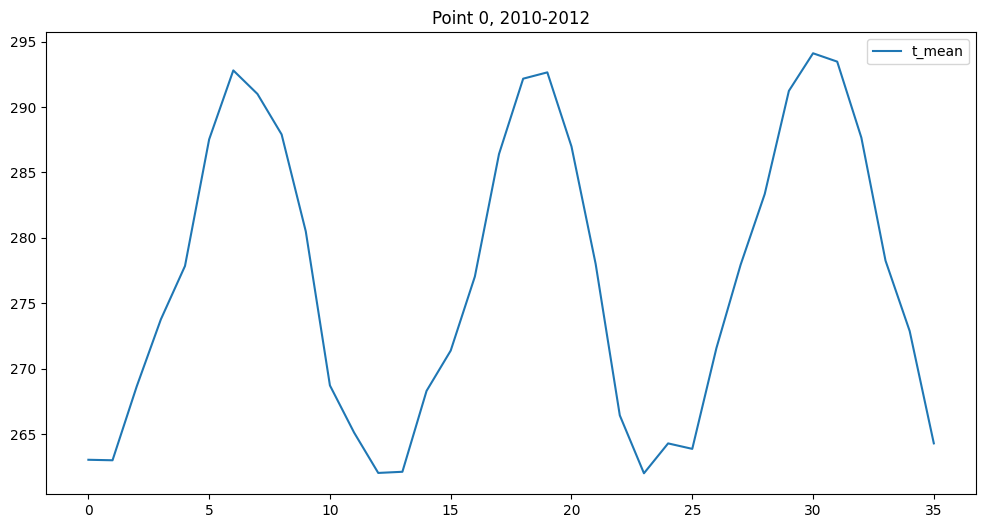

In [ ]:
a=dfOrg.loc[(dfOrg['point_id'] == 0) & (dfOrg['year'] >= 2010) & (dfOrg['year'] <= 2012)].reset_index(drop=True)
a.plot( y=[f"{TARGET_VAR}"], figsize=(12, 6), title="Point 0, 2010-2012")

In [ ]:
DYNAMIC_FEATURES

['T_anom',
 'wp',
 'nina4',
 'nao',
 'nina34',
 'ea',
 'soi',
 'ao',
 'nina1_anom',
 'nina34_anom',
 'nina3',
 'nina1',
 'pna',
 'nina4_anom',
 'nina3_anom']

## Forecast

In [ ]:
import pandas as pd

# =========================
# CONFIG
# =========================
ISSUE_YM = 2026 * 12 + 3   # March 2026

# DYNAMIC_FEATURES = [
#     "T_anom", "ea", "pna", "nino34", "nino12", "aao", "heatcentra"
# ]

LAG_MONTHS = [0,1,2,3,6,24]

# =========================
# BUILD LAGGED FEATURE LIST
# =========================
lagged_cols = [
    f"{feat}_lag{lag}"
    for feat in DYNAMIC_FEATURES
    for lag in LAG_MONTHS
]

# =========================
# BUILD MODEL INPUT DATASET
# =========================
# df must already have:
# merge_all → apply_mesh → apply_anomaly → add_seasonality → add_lags

df_model = df.dropna(subset=lagged_cols).copy()

# =========================
# GET ISSUE ROW (MARCH 2026)
# =========================
#df_issue = df_model[df_model["ym_index"] == ISSUE_YM].copy()

#CENTER_POINT = 1116

df_issue = df_model[
    (df_model["ym_index"] == ISSUE_YM) &
    (df_model["point_id"] == CENTER_POINT_ID)
].copy()



if df_issue.empty:
    raise ValueError("No March 2026 rows found — check lag creation")

# OPTIONAL: focus on single point
# df_issue = df_issue[df_issue["point_id"] == 1116]

# =========================
# BUILD FORECAST INPUT (LEADS 1–12)
# =========================
rows = []

for lead in range(1, 13):
    tmp = df_issue.copy()
    tmp["lead"] = lead
    rows.append(tmp)

df_forecast_input = pd.concat(rows, ignore_index=True)

# =========================
# MATCH TRAINING FEATURES
# =========================
feature_cols = X_train.columns.tolist()
X_input = df_forecast_input[feature_cols]

# =========================
# SCALE + PREDICT
# =========================
X_scaled = scaler.transform(X_input.values)
preds = model.predict(X_scaled, verbose=0).flatten()

df_forecast_input["prediction"] = preds

# =========================
# BUILD FORECAST DATES
# =========================
start = pd.Timestamp("2026-03-01")

df_forecast_input["forecast_date"] = [
    start + pd.DateOffset(months=int(l))
    for l in df_forecast_input["lead"]
]

df_forecast_input["target_month"] = df_forecast_input["forecast_date"].dt.month

# =========================
# ADD CLIMATOLOGY + ANOMALY
# =========================
df_forecast_input["climo"] = df_forecast_input["target_month"].map(
    lambda m: por_stats_dict[m]["mean"]
)

df_forecast_input["anomaly"] = (
    df_forecast_input["prediction"] + df_forecast_input["climo"]
)

# =========================
# FINAL OUTPUT
# =========================
df_forecast = df_forecast_input[[
    "point_id",
    "ym_index",
    "lead",
    "forecast_date",
    "target_month",
    "prediction",
    "climo",
    "anomaly"
]].copy()

print(df_forecast.head(20))

    point_id  ym_index  lead forecast_date  target_month  prediction  \
0       1116     24315     1    2026-04-01             4   -0.505687   
1       1116     24315     2    2026-05-01             5   -0.576237   
2       1116     24315     3    2026-06-01             6   -0.636240   
3       1116     24315     4    2026-07-01             7   -0.690198   
4       1116     24315     5    2026-08-01             8   -0.734201   
5       1116     24315     6    2026-09-01             9   -0.778811   
6       1116     24315     7    2026-10-01            10   -0.830175   
7       1116     24315     8    2026-11-01            11   -0.877431   
8       1116     24315     9    2026-12-01            12   -0.919008   
9       1116     24315    10    2027-01-01             1   -0.959786   
10      1116     24315    11    2027-02-01             2   -1.002076   
11      1116     24315    12    2027-03-01             3   -1.065454   

         climo     anomaly  
0   282.114256  281.608569  
1   2

In [ ]:
df.columns

Index(['point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
       'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
       ...
       'nina4_anom_lag2', 'nina4_anom_lag3', 'nina4_anom_lag6',
       'nina4_anom_lag24', 'nina3_anom_lag0', 'nina3_anom_lag1',
       'nina3_anom_lag2', 'nina3_anom_lag3', 'nina3_anom_lag6',
       'nina3_anom_lag24'],
      dtype='object', length=125)

In [ ]:
full_df[full_df["issue_ym"] == ISSUE_YM]

,point_id,issue_ym,lead,target_ym,y,lat,lon,elevation,sin_month,cos_month,...,aao_lag2,aao_lag3,aao_lag6,aao_lag24,heatcentra_lag0,heatcentra_lag1,heatcentra_lag2,heatcentra_lag3,heatcentra_lag6,heatcentra_lag24


In [ ]:
dfOrg['year_month'].max()

np.int64(202603)

In [ ]:
full_df.head()

,point_id,issue_ym,lead,target_ym,y,lat,lon,elevation,sin_month,cos_month,...,aao_lag2,aao_lag3,aao_lag6,aao_lag24,heatcentra_lag0,heatcentra_lag1,heatcentra_lag2,heatcentra_lag3,heatcentra_lag6,heatcentra_lag24
0,972,23905.0,1,23906.0,2.090959,39.8,255.9,1535.684052,0.5,0.866025,...,-0.804,-0.623,-1.22,-0.352,1.27,1.23,1.04,1.07,0.64,0.68
1,972,23905.0,2,23907.0,-0.025631,39.8,255.9,1535.684052,0.5,0.866025,...,-0.804,-0.623,-1.22,-0.352,1.27,1.23,1.04,1.07,0.64,0.68
2,972,23905.0,3,23908.0,2.631396,39.8,255.9,1535.684052,0.5,0.866025,...,-0.804,-0.623,-1.22,-0.352,1.27,1.23,1.04,1.07,0.64,0.68
3,972,23905.0,4,23909.0,1.221313,39.8,255.9,1535.684052,0.5,0.866025,...,-0.804,-0.623,-1.22,-0.352,1.27,1.23,1.04,1.07,0.64,0.68
4,972,23905.0,5,23910.0,-2.694774,39.8,255.9,1535.684052,0.5,0.866025,...,-0.804,-0.623,-1.22,-0.352,1.27,1.23,1.04,1.07,0.64,0.68


In [ ]:
print(full_df["issue_ym"].max())
print(ISSUE_YM)

24314.0
24315


In [ ]:
24312/12

2026.0

In [ ]:
2026*12+2

24314

## Analysis 

In [ ]:
dfOrg.tail()

,point_id,year_month,t_mean,td_mean,rh_mean,vpd_mean,tp_sum,days_with_rh_lt_20,rh_lt_20_pct,vpd_gt_3_pct,...,nina1_anom,nina34_anom,nina3,nina1,pna,nina4_anom,nina3_anom,lat,lon,elevation
1270327,2981,202511,284.004852,271.827540,47.827141,0.814604,0.009396,10.0,0.075000,0.004167,...,-0.46,-0.70,24.47,21.19,0.74,-0.52,-0.63,37.0,258.0,1105.270454
1270328,2981,202512,280.978013,267.189011,42.380716,0.774190,0.001578,17.0,0.137097,0.008065,...,-0.62,-0.67,24.43,22.19,-1.71,-0.33,-0.80,37.0,258.0,1105.270454
1270329,2981,202601,277.153313,263.275849,40.117993,0.616502,0.016245,18.0,0.133065,0.000000,...,-0.29,-0.58,25.02,24.28,0.36,-0.08,-0.64,37.0,258.0,1105.270454
1270330,2981,202602,283.381675,266.799279,35.434584,0.974198,0.002481,21.0,0.227679,0.008929,...,0.72,-0.27,26.31,26.82,-1.04,0.20,-0.10,37.0,258.0,1105.270454
1270331,2981,202603,288.811323,268.208378,29.208702,1.556216,0.000783,26.0,0.346774,0.116935,...,0.82,-0.06,27.41,27.31,-1.99,0.35,0.20,37.0,258.0,1105.270454


In [ ]:
X_train

,T_anom_lag0,T_anom_lag1,T_anom_lag2,T_anom_lag3,T_anom_lag6,T_anom_lag24,ea_lag0,ea_lag1,ea_lag2,ea_lag3,...,heatcentra_lag2,heatcentra_lag3,heatcentra_lag6,heatcentra_lag24,lead,lat,lon,elevation,sin_month,cos_month
0,-3.592125,-1.428437,-4.199704,0.821486,-1.414986,0.817479,2.49,1.99,-0.69,-0.86,...,1.04,1.07,0.64,0.68,1,39.8,255.9,1535.684052,5.000000e-01,0.866025
1,-3.592125,-1.428437,-4.199704,0.821486,-1.414986,0.817479,2.49,1.99,-0.69,-0.86,...,1.04,1.07,0.64,0.68,2,39.8,255.9,1535.684052,5.000000e-01,0.866025
2,-3.592125,-1.428437,-4.199704,0.821486,-1.414986,0.817479,2.49,1.99,-0.69,-0.86,...,1.04,1.07,0.64,0.68,3,39.8,255.9,1535.684052,5.000000e-01,0.866025
3,-3.592125,-1.428437,-4.199704,0.821486,-1.414986,0.817479,2.49,1.99,-0.69,-0.86,...,1.04,1.07,0.64,0.68,4,39.8,255.9,1535.684052,5.000000e-01,0.866025
4,-3.592125,-1.428437,-4.199704,0.821486,-1.414986,0.817479,2.49,1.99,-0.69,-0.86,...,1.04,1.07,0.64,0.68,5,39.8,255.9,1535.684052,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114907,-0.587854,-0.803378,2.615646,3.386075,0.729033,-0.478705,1.28,0.56,0.59,-1.67,...,1.51,1.48,1.27,0.26,8,39.4,256.3,1706.128656,-2.449294e-16,1.000000
114908,-0.587854,-0.803378,2.615646,3.386075,0.729033,-0.478705,1.28,0.56,0.59,-1.67,...,1.51,1.48,1.27,0.26,9,39.4,256.3,1706.128656,-2.449294e-16,1.000000
114909,-0.587854,-0.803378,2.615646,3.386075,0.729033,-0.478705,1.28,0.56,0.59,-1.67,...,1.51,1.48,1.27,0.26,10,39.4,256.3,1706.128656,-2.449294e-16,1.000000
114910,-0.587854,-0.803378,2.615646,3.386075,0.729033,-0.478705,1.28,0.56,0.59,-1.67,...,1.51,1.48,1.27,0.26,11,39.4,256.3,1706.128656,-2.449294e-16,1.000000


In [ ]:
import os


jja=0
djf=0
mam=0
son=0
fout=open(f"nn_month_loop_results_{TARGET_VAR}.txt", "w" )
for mo,dct in nn_results_month_loop.items():
    print(f"Month {mo:02d} | MAE: {dct['mae']:.3f} | MAE/STD: {dct['mae_norm_std']:.3f}") 
    fout.write(f"Month {mo:02d} | MAE: {dct['mae']:.3f} | MAE/STD: {dct['mae_norm_std']:.3f}\n")
    if mo in [6,7,8]:
        jja += dct['mae_norm_std']

    if mo in [12,1,2]:
        djf += dct['mae_norm_std']  
    
    if mo in [3,4,5]:
        mam += dct['mae_norm_std']
    
    if mo in [9,10,11]:
        son += dct['mae_norm_std']
fout.close()


print(f"JJA avg MAE/STD: {jja/3:.3f}")
print(f"DJF avg MAE/STD: {djf/3:.3f}")
print(f"MAM avg MAE/STD: {mam/3:.3f}")
print(f"SON avg MAE/STD: {son/3:.3f}")
fout = open(f"nn_month_loop_results_summary.txt", "a")
if not os.path.exists("nn_month_loop_results_summary.txt"):
    fout.write("target_var,jja_mae_norm_std,djf_mae_norm_std,mam_mae_norm_std,son_mae_norm_std\n")
fout.write(f"{TARGET_VAR},{jja/3:.3f},{djf/3:.3f},{mam/3:.3f},{son/3:.3f}\n")
fout.close()

NameError: name 'nn_results_month_loop' is not defined

In [ ]:
dd = pd.read_csv("por_baseline_mae_by_month_lags_3_24.csv")
stats={}
for col in dd.columns:
    if col != "month":
        jja = dd.loc[dd.month.isin([6,7,8]), col].mean()
        djf = dd.loc[dd.month.isin([12,1,2]), col].mean()
        mam = dd.loc[dd.month.isin([3,4,5]), col].mean()
        son = dd.loc[dd.month.isin([9,10,11]), col].mean()

        stats[col] = {
            "JJA": jja,
            "DJF": djf,
            "MAM": mam,
            "SON": son
        }
stats 

{'lag3': {'JJA': np.float64(0.8686666666666666),
  'DJF': np.float64(0.9696666666666666),
  'MAM': np.float64(0.8293333333333335),
  'SON': np.float64(1.0663333333333334)},
 'lag6': {'JJA': np.float64(0.876),
  'DJF': np.float64(0.9556666666666667),
  'MAM': np.float64(0.848),
  'SON': np.float64(1.0813333333333333)},
 'lag12': {'JJA': np.float64(0.9033333333333333),
  'DJF': np.float64(1.083),
  'MAM': np.float64(0.907),
  'SON': np.float64(1.1336666666666666)},
 'lag24': {'JJA': np.float64(0.8566666666666666),
  'DJF': np.float64(0.9440000000000001),
  'MAM': np.float64(0.8466666666666667),
  'SON': np.float64(1.0453333333333334)}}

In [ ]:
jja=0
djf=0
mam=0
son=0

for mo,dct in nn_results_month_loop.items():
    print(f"Month {mo:02d} | MAE: {dct['mae']:.3f} | MAE/STD: {dct['mae_norm_std']:.3f}") 
    if mo in [6,7,8]:
        jja += dct['mae_norm_std']

    if mo in [12,1,2]:
        djf += dct['mae_norm_std']  
    
    if mo in [3,4,5]:
        mam += dct['mae_norm_std']
    
    if mo in [9,10,11]:
        son += dct['mae_norm_std']

print(f"JJA avg MAE/STD: {jja/3:.3f}")
print(f"DJF avg MAE/STD: {djf/3:.3f}")
print(f"MAM avg MAE/STD: {mam/3:.3f}")
print(f"SON avg MAE/STD: {son/3:.3f}")

stats['NEW'] = {"JJA":jja/3, "DJF":djf/3, "MAM":mam/3, "SON":son/3}
fout = open(f"seasonal_skill_comparison_{TARGET_VAR}.csv", "w")
fout.write("Model,Season,JJA_MAE_STD,DJF_MAE_STD,MAM_MAE_STD,SON_MAE_STD\n")
for k,d in stats.items():
    fout.write(f"{k:6s} , {d['JJA']:.3f} , {d['DJF']:.3f} , {d['MAM']:.3f} , {d['SON']:.3f}\n")
fout.close()

Month 01 | MAE: 1.994 | MAE/STD: 0.853
Month 02 | MAE: 2.216 | MAE/STD: 1.009
Month 03 | MAE: 1.756 | MAE/STD: 0.861
Month 04 | MAE: 0.977 | MAE/STD: 0.555
Month 05 | MAE: 1.475 | MAE/STD: 0.878
Month 06 | MAE: 1.724 | MAE/STD: 0.858
Month 07 | MAE: 0.906 | MAE/STD: 0.620
Month 08 | MAE: 1.060 | MAE/STD: 0.736
Month 09 | MAE: 2.443 | MAE/STD: 1.314
Month 10 | MAE: 2.156 | MAE/STD: 1.070
Month 11 | MAE: 2.577 | MAE/STD: 0.990
Month 12 | MAE: 2.122 | MAE/STD: 0.955
JJA avg MAE/STD: 0.738
DJF avg MAE/STD: 0.939
MAM avg MAE/STD: 0.765
SON avg MAE/STD: 1.124


In [ ]:
print(f'   NEW  {stats["NEW"]["JJA"]:<6.3f}  {stats["NEW"]["DJF"]:<6.3f}  {stats["NEW"]["MAM"]:<6.3f}  {stats["NEW"]["SON"]:<6.3f}')
print(f'  LAG3  {stats["lag3"]["JJA"]:<6.3f}  {stats["lag3"]["DJF"]:<6.3f}  {stats["lag3"]["MAM"]:<6.3f}  {stats["lag3"]["SON"]:<6.3f}')
print(f'  LAG6  {stats["lag6"]["JJA"]:<6.3f}  {stats["lag6"]["DJF"]:<6.3f}  {stats["lag6"]["MAM"]:<6.3f}  {stats["lag6"]["SON"]:<6.3f}')
print(f' LAG12  {stats["lag12"]["JJA"]:<6.3f}  {stats["lag12"]["DJF"]:<6.3f}  {stats["lag12"]["MAM"]:<6.3f}  {stats["lag12"]["SON"]:<6.3f}')
print(f' LAG24  {stats["lag24"]["JJA"]:<6.3f}  {stats["lag24"]["DJF"]:<6.3f}  {stats["lag24"]["MAM"]:<6.3f}  {stats["lag24"]["SON"]:<6.3f}')

   NEW  0.738   0.939   0.765   1.124 
  LAG3  0.869   0.970   0.829   1.066 
  LAG6  0.876   0.956   0.848   1.081 
 LAG12  0.903   1.083   0.907   1.134 
 LAG24  0.857   0.944   0.847   1.045 


| Month | lag3  | lag6  | lag12 | lag24 |
| ----- | ----- | ----- | ----- | ----- |
| 1     | 0.747 | 0.800 | 0.793 | 0.787 |
| 2     | 0.982 | 0.887 | 1.017 | 0.925 |
| 3     | 0.996 | 0.883 | 0.926 | 1.003 |
| 4     | 0.680 | 0.814 | 0.736 | 0.626 |
| 5     | 0.812 | 0.847 | 1.059 | 0.911 |
| 6     | 1.015 | 1.159 | 0.965 | 1.097 |
| 7     | 0.690 | 0.697 | 0.944 | 0.653 |
| 8     | 0.901 | 0.772 | 0.801 | 0.820 |
| 9     | 1.228 | 1.247 | 1.431 | 1.066 |
| 10    | 1.016 | 1.003 | 1.029 | 1.080 |
| 11    | 0.955 | 0.994 | 0.941 | 0.990 |
| 12    | 1.180 | 1.180 | 1.439 | 1.120 |


In [ ]:
dd.to_csv("por_baseline_mae_by_month_lags_3_24.csv", index=False)

In [ ]:
import pandas as pd
import glob
import os

# 1. Define the path where you saved your wget files
path = '/home/joe/work/Fire/ML/Data/Climate-Indices/New'
all_files = glob.glob(os.path.join(path, "*.data"))  # Change extension if needed (.txt, .tsv, etc.)

# 2. Use a loop to read them in and keep only rows that start with a 4-digit year
data_frames = []

for filename in all_files:
    df = pd.read_csv(
        filename,
        sep=r"\s+",
        header=None,
        skiprows=1,
        engine="python",
        on_bad_lines="skip",
        dtype=str,
    )

    year_text = df[0].astype(str).str.strip()
    year_mask = year_text.str.fullmatch(r"\d{4}")
    df = df.loc[year_mask].copy()
    df[0] = year_text.loc[year_mask].astype(int)

    # Convert the remaining columns back to numeric where possible.
    for column in df.columns[1:]:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df['source_file'] = os.path.basename(filename)
    data_frames.append(df)

# 3. Merge everything into one DataFrame
df_master = pd.concat(data_frames, ignore_index=True)

print(f"Successfully loaded {len(data_frames)} files.")

value_cols = list(range(1, 13))
dataFramesOut=[]
for df in data_frames:
    file = df['source_file'].unique()[0]
    df[0] = pd.to_numeric(df[0], errors="coerce")  
    df = df.loc[df[0].between(1990, 2026)]    
    count = (df[value_cols] < -99).sum().sum()   
    if count > 9:
        continue    
    if df[0].max() < 2026 or df[0].min() < 1990:
        continue
    print(file, count, df[0].min(), df[0].max(), df.isna().sum().sum())
    dataFramesOut.append(df)

Successfully loaded 25 files.
wp.data 9 1990 2026 0
nina4.data 9 1990 2026 0
nao.data 9 1990 2026 0
nina34.data 9 1990 2026 0
ea.data 9 1990 2026 0
soi.data 9 1990 2026 0
ao.data 9 1990 2026 0
nina1.anom.data 9 1990 2026 0
nina34.anom.data 9 1990 2026 0
nina3.data 9 1990 2026 0
nina1.data 9 1990 2026 0
pna.data 9 1990 2026 0
nina4.anom.data 9 1990 2026 0
nina3.anom.data 9 1990 2026 0


In [ ]:
long_frames = []

for df in dataFramesOut:
    index_name = os.path.splitext(df['source_file'].unique()[0])[0].replace(".", "_")

    # Melt the 12 month columns (1–12) into rows
    melted = df.melt(id_vars=[0], value_vars=list(range(1, 13)),
                     var_name="month", value_name=index_name)

    # Build YYYYMM key
    melted["yrmo"] = melted[0].astype(int) * 100 + melted["month"].astype(int)

    # Replace missing-value flags with NaN
    melted.loc[melted[index_name] < -99, index_name] = float("nan")

    melted = melted[["yrmo", index_name]].sort_values("yrmo").reset_index(drop=True)
    long_frames.append(melted)

# Merge all indices on yrmo
from functools import reduce
idx_new = reduce(lambda a, b: a.merge(b, on="yrmo", how="outer"), long_frames)
idx_new = idx_new.sort_values("yrmo").reset_index(drop=True)

# Remove months where every index value is missing
value_cols = [c for c in idx_new.columns if c != "yrmo"]
idx_new = idx_new.dropna(subset=value_cols, how="all").reset_index(drop=True)

print(idx_new.shape)
print(idx_new.head())

# Persist to the new DB
DB_PATH_NEW = os.path.join(path_clim, "New", "climate_indices.db")
with sqlite3.connect(DB_PATH_NEW) as conn:
    idx_new.to_sql("indices", conn, if_exists="replace", index=False)
    print(f"\nWrote indices table ({len(idx_new)} rows × {len(idx_new.columns)} cols) → {DB_PATH_NEW}")

(435, 15)
     yrmo    wp  nina4   nao  nina34    ea  soi     ao  nina1_anom  \
0  199001  1.37  28.48  0.70   26.56  0.18 -0.1  1.001       -0.48   
1  199002  0.24  28.58  1.16   26.96 -0.14 -3.0  3.402       -0.16   
2  199003 -0.13  28.63  1.13   27.33 -0.03 -0.7  2.990       -0.44   
3  199004 -0.84  28.75  2.03   27.90 -1.11  0.3  1.879       -0.52   
4  199005  0.17  28.85 -1.37   28.02  2.25  2.0  0.943       -0.24   

   nina34_anom  nina3  nina1   pna  nina4_anom  nina3_anom  
0         0.01  25.37  24.09 -1.09        0.16       -0.29  
1         0.21  26.42  25.94 -2.78        0.38        0.01  
2         0.04  26.92  26.04  0.04        0.31       -0.28  
3         0.08  27.49  25.02 -0.62        0.12       -0.10  
4         0.08  27.41  24.18  0.27       -0.06        0.16  

Wrote indices table (435 rows × 15 cols) → /home/joe/work/Fire/ML/Data/Climate-Indices/New/climate_indices.db


In [ ]:
DB_PATH_NEW = os.path.join(path_clim, "New", "climate_indices.db")

conn = sqlite3.connect(DB_PATH_NEW)
idx = pd.read_sql(f"SELECT * FROM indices", conn)
conn.close()

# idx = idx.rename(columns={
#     "ea.data": "ea",
#     "pna.data": "pna",
#     "nino34.long.anom.data": "nino34",
#     "nino12.long.anom.data": "nino12",
#     "aao.data": "aao",
#     "heatcentra.data": "heatcentra"
# })

In [ ]:
idx.columns

Index(['yrmo', 'wp', 'nina4', 'nao', 'nina34', 'ea', 'soi', 'ao', 'nina1_anom',
       'nina34_anom', 'nina3', 'nina1', 'pna', 'nina4_anom', 'nina3_anom'],
      dtype='object')

In [ ]:
idx.drop(columns=["yrmo"]).columns

Index(['wp', 'nina4', 'nao', 'nina34', 'ea', 'soi', 'ao', 'nina1_anom',
       'nina34_anom', 'nina3', 'nina1', 'pna', 'nina4_anom', 'nina3_anom'],
      dtype='object')